## music service chatbot

### 목적 : 
- 차량 운전중 음악 추천 
- 날씨에 어울리는 음악 추천
- A곡과 비슷한 B곡 추천
- PDF 기반 검색
- 수집된 데이터 기반 python 코드 활용 차트 비교
- CS 상담



Q : 오늘 날씨에 어울리는 재즈 추천해줘, 내가 사는 곳은 서울이야

feedback_node : no

plan_node : 

[오늘 서울 날씨에 어울리는 재즈 음악 목록을 생성합니다.

생성된 음악 목록에서 서비스에서 이용 가능한 음악을 검증합니다.

최종 음악 목록을 선정하여 추천합니다.]

start_node -> routing

final_node -> tool 사용 여부 확인

A :  web_search_agent 사용하여 진행할까여 ?

Q : 응 검색해

feedback_node : yes

start_node -> routing

agent 사용 -> 검색 결과 제시

final_node -> 검색 내용 기반 최종 답변

A :  web_search_agent,  query: 오늘 서울 날씨


### 기본 구성

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *

In [2]:
start_langsmith("final_music")

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music


In [3]:
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

### SQL graph

In [4]:
class SubState(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    current_steps: Annotated[str, "current step"]  # 현재 단계에서 수행한 결과
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    db_query: Annotated[str, "db_query"]  # 현재 단계에서 수행한 결과

In [5]:
@tool
def db_query_tool(query: str) -> str:
    """
    Run SQL queries against a database and return results
    Returns an error message if the query is incorrect
    If an error is returned, rewrite the query, check, and retry
    """
    # 쿼리 실행
    db = get_db()
    result = db.run_no_throw(query)

    # 오류: 결과가 없으면 오류 메시지 반환
    if "Error" in result:
        return f"Error: {result} \n\n . Please rewrite your query and try again."
    # 정상: 쿼리 실행 결과 반환
    elif not result:
        return "Success: value is None"
    else:
        return f"Success: {result}"

In [6]:
def instruction_node(state: SubState):
    plan = state["plan"]
    text_plan = "\n".join(f"{idx+1}. {text}" for idx, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {text_plan} \n\n You are tasked with executing [step 1. {task}]."""
    return SubState({"messages": task_str, "current_steps": task_str})


def get_table_list_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_list_tables = next(
        tool for tool in tools if tool.name == "sql_db_list_tables"
    )
    llm_get_schema = llm.bind_tools(
        [sql_db_list_tables], tool_choice="sql_db_list_tables"
    )
    return SubState({"messages": llm_get_schema.invoke("")})


def get_all_table_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_list_tables = next(
        tool for tool in tools if tool.name == "sql_db_list_tables"
    )
    return ToolNode([sql_db_list_tables])


def get_one_table_info_node(state: SubState):
    llm = get_gpt()
    tools = get_db_tool(llm)
    sql_db_schema = next(tool for tool in tools if tool.name == "sql_db_schema")
    llm_with_schema = llm.bind_tools([sql_db_schema], tool_choice="sql_db_schema")
    state_message = state["messages"][-3:]
    result = llm_with_schema.invoke(state_message)
    return SubState({"messages": result})


def get_one_table_schema_node(state: SubState):
    llm = get_gemini()
    tools = get_db_tool(llm)
    sql_db_schema = next(tool for tool in tools if tool.name == "sql_db_schema")
    return ToolNode([sql_db_schema])


def get_query_gen_node(state: SubState):
    prompt = get_prompt_query_gen()
    llm = get_gpt()
    # query_gen_llm = prompt | llm.bind_tools(
    #     [db_query_tool], tool_choice="db_query_tool"
    # )
    query_gen_llm = prompt | llm
    history = state["messages"]
    current_steps = state["current_steps"]
    query_gen = query_gen_llm.invoke(
        {"placeholder": history, "current_steps": current_steps}
    )
    db_query = query_gen.content
    # db_query = query_gen.tool_calls[0]["args"]["query"]
    return SubState({"messages": query_gen, "db_query": db_query})


def check_query_relavant(state: SubState):
    prompt = get_prompt_relevant_query()
    llm = get_gpt()
    query_gen_llm = prompt | llm.with_structured_output(GradeQuery)
    current_steps = state["current_steps"]
    query = state["db_query"]
    query_gen = query_gen_llm.invoke({"current_steps": current_steps, "query": query})
    return SubState({"messages": query_gen.datasource})


def execute_query(state: SubState):
    query = state["db_query"]
    response = db_query_tool(query)
    return SubState({"messages": AIMessage(content=response)})


#  실패시 get_query_check_node -> execute_query 로직 추가
def get_query_check_node(state: SubState):
    prompt = get_prompt_query_check()
    llm = get_gpt().bind_tools([db_query_tool], tool_choice="db_query_tool")
    chain = prompt | llm
    history = state["messages"][-1].tool_calls[0]["args"]["query"]
    query_gen = chain.invoke({"placeholder": [history]})
    return SubState({"messages": [query_gen]})


def answer_node(state: SubState):
    prompt = get_prompt_answer()
    llm = get_gpt()
    query_gen_llm = prompt | llm
    history = state["messages"]
    current_steps = state["current_steps"]
    result = query_gen_llm.invoke(
        {"placeholder": history, "current_steps": current_steps}
    )
    return SubState(
        {
            "past_steps": [result],
            "messages": [result],
        }
    )

In [7]:
def query_relevant(
    state: SubState,
) -> Literal["execute_query", "get_one_table_info_node"]:
    latest_messages: str = state["messages"][-1].content
    if latest_messages == "yes":
        return "execute_query"
    else:
        return "get_one_table_info_node"

In [8]:
sub_state_graph = StateGraph(SubState)
sub_state_graph.add_node("instruction_node", instruction_node)
sub_state_graph.add_node("get_table_list_node", get_table_list_node)
sub_state_graph.add_node("get_all_table_node", get_all_table_node)
sub_state_graph.add_node("get_one_table_info_node", get_one_table_info_node)
sub_state_graph.add_node("get_one_table_schema_node", get_one_table_schema_node)
sub_state_graph.add_node("get_query_gen_node", get_query_gen_node)
sub_state_graph.add_node("check_query_relavant", check_query_relavant)

sub_state_graph.add_node("get_query_check_node", get_query_check_node)
sub_state_graph.add_node("execute_query", execute_query)
sub_state_graph.add_node("answer_node", answer_node)


sub_state_graph.add_edge(START, "instruction_node")
sub_state_graph.add_edge("instruction_node", "get_table_list_node")
sub_state_graph.add_edge("get_table_list_node", "get_all_table_node")
sub_state_graph.add_edge("get_all_table_node", "get_one_table_info_node")
sub_state_graph.add_edge("get_one_table_info_node", "get_one_table_schema_node")
sub_state_graph.add_edge("get_one_table_schema_node", "get_query_gen_node")
sub_state_graph.add_edge("get_query_gen_node", "check_query_relavant")
sub_state_graph.add_conditional_edges(
    source="check_query_relavant", path=query_relevant
)

sub_state_graph.add_edge("execute_query", "answer_node")
sub_state_graph.add_edge("answer_node", END)

sub_ck = get_check_pointer()
sub_graph = sub_state_graph.compile(checkpointer=sub_ck)

### main graph

In [9]:
class State(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    current_steps: Annotated[str, "current step"]  # 현재 단계에서 수행한 결과
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    db_query: Annotated[str, "db_query"]  # 현재 단계에서 수행한 결과
    next_agent: Annotated[str, " use agent"]

In [10]:
path_template = """
    # System :
    You are an AI assistant 
    You can judge the user's input and Ai answer, make decisions

    # Previous AI Answers :
    {answer}

    # User input :
    {question}

    
    # Rules :
    Output 'response_node' when a request is received to agree or accept the Prevalent AI Answers

    Otherwise, output 'request_node' if the value of 'quest' is a new proposal, a suggestion that does not matter to Prevalent AI Answers

    In the case of 'response_node', we will try to resolve your request using agent.

    In the case of 'request_node', we will be responsible for developing a plan to resolve the proposal.

    # Important :
    The answer must be one of three
    The answer is available in Korean
"""
path_prompt = ChatPromptTemplate.from_template(path_template)

final_template = """ 
    # System :
    You are an AI assistant
    Depending on your needs, you can use a number of tools or solve problems yourself.
    If you decide to use the tool or solve the problem yourself, make sure to do so after getting confirmation from the user

    # History : 
    {messages}

    # next_agent :
    {next_agent}


    # Impotant : 
    If next_agent is `no agent`, print your final answer based on your previous record.
    If next_agent is not `no agent`, you must to generate a message confirming whether you want to agent use it or not.Be sure to present one action

    Write your response in Korean.
    """
final_prompt = ChatPromptTemplate.from_template(final_template)


def get_prompt_music_planner1() -> ChatPromptTemplate:
    """
    주어진 question을 기반으로 step 별 계획을 세우는 prompt
    value = 'messages'
    """
    templete = """
    Infomation : 
    I live in Seoul,KR
    
    System : 
    you must call `PlanListModel`
    If you don't need a plan, output the question in `PlanListModel.steps`.
    For the given objective, come up with a simple step by step plan. \
    This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
    The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

    Example :
    Question: Please recommend a song that fits today's weather
    Step 1. : 
    Step 2. :
    Step 3. :

    Answer : 
    stpes : ["Sample 1","Sample 2","Sample 3"]
    If you don't need a plan, output the question in `steps`.
    If there is no plan, output the question in `steps`.
    Answer in Korean."""
    return ChatPromptTemplate.from_messages(
        [
            ("system", templete),
            ("placeholder", "{messages}"),
        ]
    )

In [11]:
def db_toolkit():
    db = SQLDatabase.from_uri("sqlite:///Chinook.db")
    toolkit = SQLDatabaseToolkit(db=db, llm=get_gpt())
    return toolkit.get_tools()

In [12]:
def web_search_agent(state: State):
    plan = state["plan"]
    plan_str = "\n".join(f"{i+1}. {text}" for i, text in enumerate(plan))
    task = plan[0]
    task_str = f"""For the following plan: \n\n {plan_str} \n\n You are tasked with executing [step 1. {task}]."""
    prompt = get_prompt_web()
    llm = get_gemini()
    tavily = get_tavily_tool()
    tools = [tavily, get_weather]
    web_agent = create_react_agent(model=llm, tools=tools, prompt=prompt)
    result = web_agent.invoke({"messages": task_str})
    latest_messages = f" Question :{task}\n Response :{result['messages'][-1].content}"
    return State({"past_steps": [latest_messages], "messages": [latest_messages]})

In [ ]:
def feedback_node(state: State):
    answer = state.get("answer", "")
    llm = get_gemini()
    chain = path_prompt | llm.with_structured_output(FeedbackModel)
    result = chain.invoke({"question": state["question"], "answer": answer})
    return State(
        {
            "human_feedback": result.datasource,
            "messages": AIMessage(content=result.datasource),
        }
    )


def plan_node(state: State) -> State:
    llm = get_gemini()
    prompt = get_prompt_music_planner1()
    chain = prompt | llm.with_structured_output(PlanListModel)
    result = chain.invoke({"messages": [state["question"]]})
    return State({"plan": result.steps})

def replan_node(state: State):
    prompt = get_prompt_replanner()
    llm = get_gpt()
    chain = prompt | llm.with_structured_output(PlanListModel)
    result = chain.invoke(
        {
            "input": state["question"],
            "plan": state["plan"],
            "past_steps": state["past_steps"][-1].content,
        }
    )
    return State({"plan": result.steps})

def routing_node(state: State):
    plan = state["plan"]
    task = plan[0]
    prompt = get_prompt_routing_node()
    llm = get_gemini()
    chain = prompt | llm.with_structured_output(RouteModel)
    result = chain.invoke({"placeholder": [task]})
    response = f"실행 계획 : {task} \n 사용 도구 : {result.datasource}"
    return State(
        {
            "messages": AIMessage(content=response),
            "next_agent": result.datasource,
        }
    )


def final_node(state: State):
    llm = get_gemini()
    chain = final_prompt | llm
    result = chain.invoke(
        {"messages": state["messages"], "next_agent": state["next_agent"]}
    )
    return State({"messages": [result], "answer": result.content})

In [14]:
def is_routing_agent(
    state: State,
) -> Literal[
    "plan_node",
    "web_search_agent",
    "sub_graph",
]:
    human_feedback = state["human_feedback"]
    if human_feedback == "request_node":
        return "plan_node"
    else:
        datasource = state["next_agent"]
        if datasource == "web_search_agent":
            return "web_search_agent"
        elif datasource == "db_agent":
            return "sub_graph"


def should_continue(state: State) -> Literal["final_node", "routing_node"]:
    if "answer" in state and state["answer"]:
        return "final_node"
    else:
        return "routing_node"
    
def is_plan(state: State)->Literal['routing_node','final_node']:
    if len(state['plan']) >0:
        return 'routing_node'
    else :
        return 'final_node'

In [15]:
state_graph = StateGraph(State)
state_graph.add_node("feedback_node", feedback_node)
state_graph.add_node("plan_node", plan_node)
state_graph.add_node("replan_node", replan_node)

state_graph.add_node("routing_node", routing_node)
state_graph.add_node("web_search_agent", web_search_agent)
state_graph.add_node("sub_graph", sub_graph)
state_graph.add_node("final_node", final_node)

state_graph.add_edge(START, "feedback_node")
state_graph.add_conditional_edges(source="feedback_node", path=is_routing_agent)
state_graph.add_conditional_edges(source="plan_node", path=is_plan)

state_graph.add_edge("sub_graph", "replan_node")
state_graph.add_edge("web_search_agent", "replan_node")
state_graph.add_conditional_edges(source="replan_node", path=is_plan)

state_graph.add_edge("routing_node", "final_node")
state_graph.add_edge("final_node", END)
# state_graph.add_conditional_edges(source="replan_node", path=should_continue)

# state_graph.add_edge("web_search_agent", "replan_node")


# state_graph.add_edge("routing_node", "final_node")
# state_graph.add_edge("final_node", END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

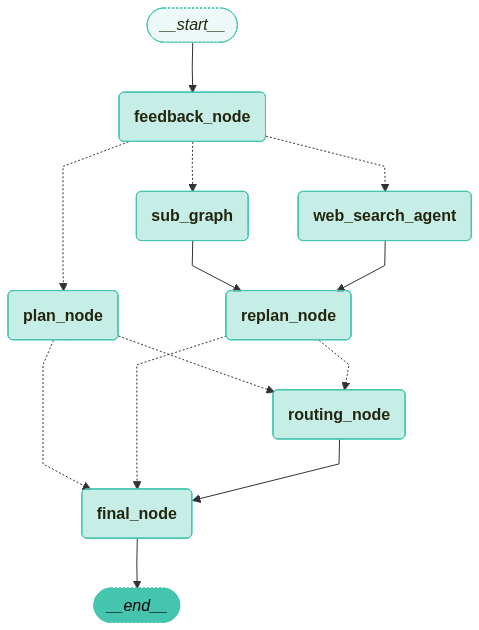

In [16]:
visualize_graph(graph)

In [17]:
def message_parser(event):
    print("=========" * 10 + "\n\n")
    print(f"question : {event['question']}\n")
    print(f"human_feedback : {event.get('human_feedback')}\n")
    print(f"next_agent : {event.get('next_agent')}\n")
    print(f"plan : {event.get('plan')}\n")
    print(f"past_steps : {event.get('past_steps')}\n")
    print(f"messages : {get_messages(event)}\n")
    print(f"answer : {event.get('answer')}\n")
    print("=========" * 10 + "\n\n")

def get_messages(event):
    messages = event.get('messages')
    if len(messages) == 0 :
        return ''
    else :
        return messages[-1]
    
def parse_messages(messages):
    parsed = []
    for msg in messages:
        if isinstance(msg, HumanMessage):
            parsed.append(f"human : {msg.content}")
        elif isinstance(msg, AIMessage):
            parsed.append(f"ai : {msg.content}")
        elif isinstance(msg, ToolMessage):
            parsed.append(f"tool : {msg.content}")
        else:
            parsed.append(f"etc : {msg.content}")
    return parsed


In [32]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())

question = "안녕 난 Kara Nielsen 이야"
inputs = {"question": question, "messages": question}

for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

In [33]:
first_snapshot = graph.get_state(config)
parse_messages(first_snapshot.values["messages"])

['human : 안녕 난 Kara Nielsen 이야',
 'ai : request_node',
 'ai : 실행 계획 : Kara Nielsen님, 안녕하세요! 만나서 반갑습니다. \n 사용 도구 : no_agent',
 'ai : 안녕하세요, Kara Nielsen님! 만나서 반갑습니다.']

In [34]:
question = "내 FavoriteMusic 어떤 곡이 존재하는지 알려줘"
inputs = {"question": question, "messages": question}
for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

In [35]:
second_snapshot = graph.get_state(config)
parse_messages(second_snapshot.values["messages"])

['human : 안녕 난 Kara Nielsen 이야',
 'ai : request_node',
 'ai : 실행 계획 : Kara Nielsen님, 안녕하세요! 만나서 반갑습니다. \n 사용 도구 : no_agent',
 'ai : 안녕하세요, Kara Nielsen님! 만나서 반갑습니다.',
 'human : 내 FavoriteMusic 어떤 곡이 존재하는지 알려줘',
 'ai : request_node',
 'ai : 실행 계획 : 사용자의 FavoriteMusic 목록을 조회합니다. \n 사용 도구 : db_agent',
 'ai : Kara Nielsen님의 FavoriteMusic 목록을 조회하겠습니다. 이 작업에 db_agent를 사용해도 될까요?']

In [36]:
question = "ㄱㄱ"
inputs = {"question": question, "messages": question}
for event in graph.stream(
    inputs,
    config=config,
    stream_mode="values",
):
    message_parser(event)



question : ㄱㄱ

human_feedback : request_node

next_agent : db_agent

plan : ['사용자의 FavoriteMusic 목록을 조회합니다.', '조회된 FavoriteMusic 목록을 사용자에게 알려줍니다.']

past_steps : []

messages : content='ㄱㄱ' additional_kwargs={} response_metadata={} id='0c5d22d7-c422-48c6-afc4-475612a6fa5a'

answer : Kara Nielsen님의 FavoriteMusic 목록을 조회하겠습니다. 이 작업에 db_agent를 사용해도 될까요?





question : ㄱㄱ

human_feedback : response_node

next_agent : db_agent

plan : ['사용자의 FavoriteMusic 목록을 조회합니다.', '조회된 FavoriteMusic 목록을 사용자에게 알려줍니다.']

past_steps : []

messages : content='response_node' additional_kwargs={} response_metadata={} id='84c5133d-fdc2-4599-b854-c13e9d64b402'

answer : Kara Nielsen님의 FavoriteMusic 목록을 조회하겠습니다. 이 작업에 db_agent를 사용해도 될까요?





question : ㄱㄱ

human_feedback : response_node

next_agent : db_agent

plan : ['사용자의 FavoriteMusic 목록을 조회합니다.', '조회된 FavoriteMusic 목록을 사용자에게 알려줍니다.']

past_steps : [AIMessage(content='Kara Nielsen님의 FavoriteMusic 목록을 성공적으로 조회했습니다.\n\n현재 Kara Nielsen님이 즐겨찾기한 음악의 TrackId는 다음

In [37]:
third_snapshot = graph.get_state(config, subgraphs=True)
# third_snapshot.values
parse_messages(third_snapshot.values["messages"])

['human : 안녕 난 Kara Nielsen 이야',
 'ai : request_node',
 'ai : 실행 계획 : Kara Nielsen님, 안녕하세요! 만나서 반갑습니다. \n 사용 도구 : no_agent',
 'ai : 안녕하세요, Kara Nielsen님! 만나서 반갑습니다.',
 'human : 내 FavoriteMusic 어떤 곡이 존재하는지 알려줘',
 'ai : request_node',
 'ai : 실행 계획 : 사용자의 FavoriteMusic 목록을 조회합니다. \n 사용 도구 : db_agent',
 'ai : Kara Nielsen님의 FavoriteMusic 목록을 조회하겠습니다. 이 작업에 db_agent를 사용해도 될까요?',
 'human : ㄱㄱ',
 'ai : response_node',
 'human : For the following plan: \n\n 1. 사용자의 FavoriteMusic 목록을 조회합니다.\n2. 조회된 FavoriteMusic 목록을 사용자에게 알려줍니다. \n\n You are tasked with executing [step 1. 사용자의 FavoriteMusic 목록을 조회합니다.].',
 'ai : ',
 'tool : Album, Artist, Customer, Employee, FavoriteMusic, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track',
 'ai : ',
 'tool : \nCREATE TABLE "FavoriteMusic" (\n\t"FavoriteMusicId" INTEGER, \n\t"CustomerId" INTEGER NOT NULL, \n\t"TrackId" INTEGER NOT NULL, \n\tPRIMARY KEY ("FavoriteMusicId"), \n\tFOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId"), 

In [38]:
question = "ㅇㅇ 진행해"
inputs = {"question": question, "messages": question}
for event in graph.stream(
    inputs,
    config=config,
    stream_mode="values",
):
    message_parser(event)



question : ㅇㅇ 진행해

human_feedback : response_node

next_agent : db_agent

plan : ['조회된 FavoriteMusic 목록의 TrackId를 사용하여 각 음악 트랙의 상세 정보를 조회합니다.', '조회된 음악 트랙의 상세 정보를 사용자에게 알려줍니다.']

past_steps : [AIMessage(content='Kara Nielsen님의 FavoriteMusic 목록을 성공적으로 조회했습니다.\n\n현재 Kara Nielsen님이 즐겨찾기한 음악의 TrackId는 다음과 같습니다:\n- 3256\n- 3268\n- 325\n- 326\n- 330\n\n이 목록은 Kara Nielsen님이 즐겨 듣는 음악 트랙들의 고유 식별자입니다. 다음 단계로, 이 트랙들의 상세 정보를 조회하여 Kara Nielsen님께 알려드릴 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 2285, 'total_tokens': 2383, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-COlsS4SuMOo1teMi10kS7pNQpddtA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None},

In [39]:
four_snapshot = graph.get_state(config, subgraphs=True)
# third_snapshot.values
parse_messages(four_snapshot.values["messages"])

['human : 안녕 난 Kara Nielsen 이야',
 'ai : request_node',
 'ai : 실행 계획 : Kara Nielsen님, 안녕하세요! 만나서 반갑습니다. \n 사용 도구 : no_agent',
 'ai : 안녕하세요, Kara Nielsen님! 만나서 반갑습니다.',
 'human : 내 FavoriteMusic 어떤 곡이 존재하는지 알려줘',
 'ai : request_node',
 'ai : 실행 계획 : 사용자의 FavoriteMusic 목록을 조회합니다. \n 사용 도구 : db_agent',
 'ai : Kara Nielsen님의 FavoriteMusic 목록을 조회하겠습니다. 이 작업에 db_agent를 사용해도 될까요?',
 'human : ㄱㄱ',
 'ai : response_node',
 'human : For the following plan: \n\n 1. 사용자의 FavoriteMusic 목록을 조회합니다.\n2. 조회된 FavoriteMusic 목록을 사용자에게 알려줍니다. \n\n You are tasked with executing [step 1. 사용자의 FavoriteMusic 목록을 조회합니다.].',
 'ai : ',
 'tool : Album, Artist, Customer, Employee, FavoriteMusic, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track',
 'ai : ',
 'tool : \nCREATE TABLE "FavoriteMusic" (\n\t"FavoriteMusicId" INTEGER, \n\t"CustomerId" INTEGER NOT NULL, \n\t"TrackId" INTEGER NOT NULL, \n\tPRIMARY KEY ("FavoriteMusicId"), \n\tFOREIGN KEY("CustomerId") REFERENCES "Customer" ("CustomerId"), 

In [40]:
question = "이중에서 비오는날 듣기좋은곡 하나 추천해줘"
inputs = {"question": question, "messages": question}
for event in graph.stream(
    inputs,
    config=config,
    stream_mode="values",
):
    message_parser(event)



question : 이중에서 비오는날 듣기좋은곡 하나 추천해줘

human_feedback : response_node

next_agent : db_agent

plan : ['Kara Nielsen님께 조회된 음악 트랙의 상세 정보를 안내합니다.']

past_steps : [AIMessage(content='Kara Nielsen님의 FavoriteMusic 목록을 성공적으로 조회했습니다.\n\n현재 Kara Nielsen님이 즐겨찾기한 음악의 TrackId는 다음과 같습니다:\n- 3256\n- 3268\n- 325\n- 326\n- 330\n\n이 목록은 Kara Nielsen님이 즐겨 듣는 음악 트랙들의 고유 식별자입니다. 다음 단계로, 이 트랙들의 상세 정보를 조회하여 Kara Nielsen님께 알려드릴 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 2285, 'total_tokens': 2383, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_c064fdde7c', 'id': 'chatcmpl-COlsS4SuMOo1teMi10kS7pNQpddtA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--6ced963d-e46d-4a19-8883-d0

In [26]:
# to_replay = None

# # 상태 기록 가져오기
# for i, state in enumerate(graph.get_state_history(config)):
#     # 메시지 수 및 다음 상태 출력
#     print(i)
#     print(state.values)
#     print("\n\n")
#     if i == 2:
#         to_replay = state

In [27]:
# plan = ['오늘 서울 날씨 확인 후 오늘 날씨에 어울리는 재즈 음악 5곡 웹에서 검색하여 추천', '추천한 재즈 음악이 서비스에 있는지 확인', '최종 추천 목록 생성']
# updated_state = graph.update_state(
#     # 업데이트할 상태 지정
#     to_replay.config,
#     # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
#     {"plan": plan},
# )
# for event in graph.stream(None, updated_state, stream_mode="values"):
#     print(event)

In [28]:
# snapshot = graph.get_state(config)
# print(snapshot)

In [29]:
# inputs = {"question": "ㅇㅇ 그렇게해"}
# for event in graph.stream(inputs,config=config,stream_mode='values'):
#     print(event)
#     print("========="*10+"\n\n")

In [30]:
# inputs = {"question": "팝송 5곡 추천해줘"}
# stream_graph(graph, inputs, config)